# Streaming anomaly detection on fixed-angle projection movies

Builds directly on `wunderkerze_rotation_calibration.ipynb`. There we established that
`212_Wunderkerze2` rotates at a constant **≈1.8014 °/frame** (period ≈199.84 frames/360°) and
that a *fixed-angle time-lapse* — one interpolated frame per turn — shows the **sample
evolving over time** at a locked viewpoint.

Here we watch those fixed-angle movies **on the fly** for anomalies, using the new
`sdate.anomaly` library. For each tracked angle we keep a sliding-window PCA reference and
score every incoming frame with two complementary statistics:

* **Hotelling's T²** — the frame is extreme *along modes the model already knows*.
* **Q / SPE** — the frame contains *novel structure outside the modelled subspace*.

Each statistic also yields a per-pixel **contribution mask** localising *where* on the
detector the anomaly is. Running several angles in parallel lets us **majority-vote** an
anomaly (robustness) and, later, triangulate it in 3D.

The library is *source-agnostic*: it exposes `detector.push(frame, idx)` and an external
orchestrator (`sdate.anomaly.sources.mov_frame_stream`) feeds it — swap in HDF5 or a live
detector socket without touching the detector.

In [ ]:
import sys; sys.path.insert(0, "/myhome/sdate")
import numpy as np, matplotlib.pyplot as plt, time
from sdate.anomaly import CalibrationConfig, DetectorConfig, AnomalyDetector, aggregate_votes
from sdate.anomaly.calibrate import calibrate_from_frames
from sdate.anomaly.sources import mov_frame_stream
from sdate.anomaly import viz
from sdate.anomaly.movies import export_overlay_movie

START = 410000        # same range as the calibration notebook
%matplotlib inline

## 1. Preprocessing / calibration

Everything the detector treats as *known in advance* lives in a `CalibrationConfig`
(`deg_per_frame`, rotation `axis`, flats/darks, `ref_frame`). When a value is missing we
estimate it from a warm-up slice of the stream — `deg_per_frame` from identity
autocorrelation, `axis` from 180°-mirror overlap — the same methods validated in the
calibration notebook. Flats/darks aren't provided for this dataset, so preprocessing falls
back to per-frame flux normalisation + the per-angle PCA mean.

In [2]:
warm = np.stack([f for _, f in mov_frame_stream(START, 600)])
calib = calibrate_from_frames(warm, ref_frame=START, with_axis=True)
print(f"deg_per_frame = {calib.deg_per_frame:.6f}   (calibration notebook: 1.801402)")
print(f"period(360)   = {calib.period:.3f} frames")
print(f"rotation axis = {calib.axis:.2f} px   (calibration notebook: 269.85)")
# If you already trust the calibration, just hard-set it:
# calib = CalibrationConfig(frame_shape=(128,528), deg_per_frame=1.801402, ref_frame=START, axis=269.85)

deg_per_frame = 1.801435   (calibration notebook: 1.801402)
period(360)   = 199.841 frames
rotation axis = 269.39 px   (calibration notebook: 269.85)


## 2. Stream frames through the detector

We track a few fixed angles (v1) and stream ~20k frames (~100 turns). `push()` routes each
raw frame into every tracked angle's sub-stream via sub-frame interpolation, preprocesses the
synthesised fixed-angle frame, scores it, and records frame + masks for the viewers.

In [ ]:
cfg = DetectorConfig(
    target_angles=(0.0, 90.0, 270.0),   # a few angles for v1; widen to a uniform subset later
    n_modes=6, window=30, min_turns=12,
    gate_k=6.0, thr_min_history=12,      # robust control-chart limit = median + 6*1.4826*MAD
    flux_normalize=True, record_frames=True,
)
det = AnomalyDetector(calib, cfg)

N = 40000
t0 = time.time()
for idx, frame in mov_frame_stream(START, N):
    det.push(frame, idx)
print(f"streamed {det.n_pushed} frames in {time.time()-t0:.0f}s; gaps skipped={det.mux.skipped_gaps}")
for ai, r in det.results.items():
    print(f"  angle {r.angle:6.1f}°: {len(r.scores)} turns | Q flags={int(r.q_flags.sum())} "
          f"| T² flags={int(r.t2_flags.sum())}")

streamed 20000 frames in 284s; gaps skipped=0
  angle    0.0°: 101 turns | Q flags=19 | T² flags=0
  angle   90.0°: 100 turns | Q flags=19 | T² flags=2
  angle  270.0°: 100 turns | Q flags=19 | T² flags=2


## 3. Anomaly curves across angles (majority voting)

One row per tracked angle. Dashed red = adaptive control limit; red dots = flagged turns.
Turns flagged from **several angles at once** are the robust detections — that's what
`aggregate_votes` counts. Compare the Q (novel structure) and T² (extreme-but-known) panels;
they intentionally fire on different things.

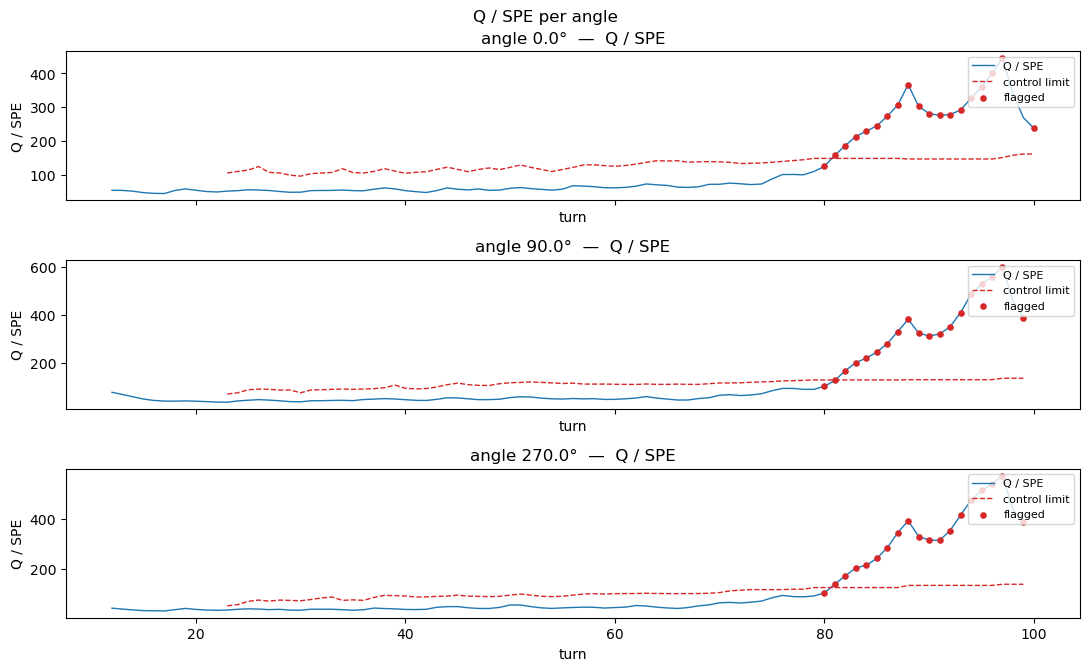

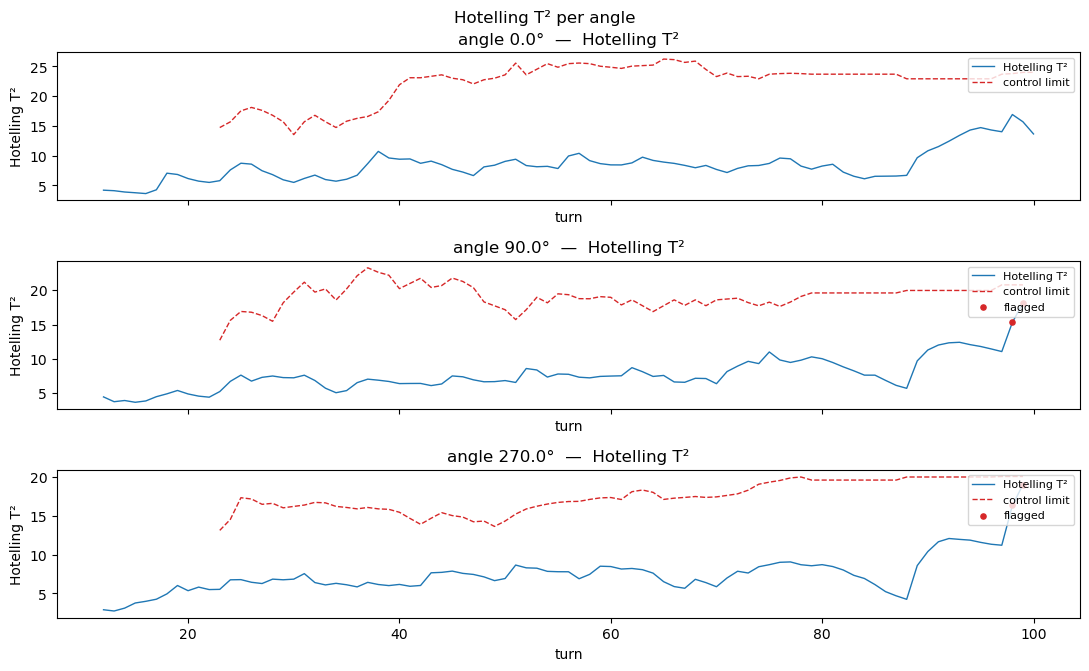

majority (2/3) confirmed Q turns : [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99]
majority (2/3) confirmed T² turns: [98, 99]


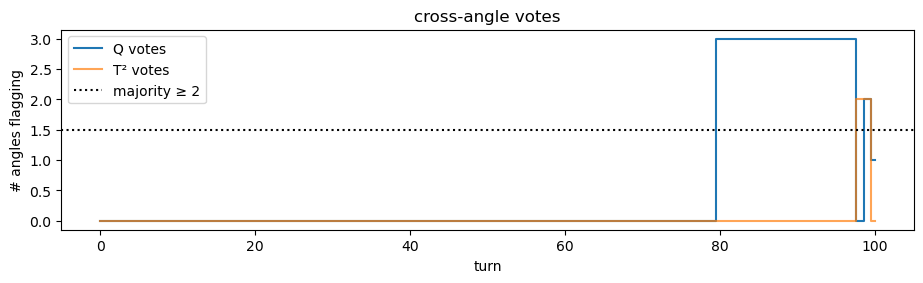

In [4]:
viz.plot_all_angles(det, which="q");   plt.suptitle("Q / SPE per angle", y=1.01); plt.show()
viz.plot_all_angles(det, which="t2");  plt.suptitle("Hotelling T² per angle", y=1.01); plt.show()

vr = aggregate_votes(det.results)   # strict majority by default
print(f"majority ({vr.min_votes}/{vr.n_angles}) confirmed Q turns : {vr.turns[vr.q_confirmed].tolist()}")
print(f"majority ({vr.min_votes}/{vr.n_angles}) confirmed T² turns: {vr.turns[vr.t2_confirmed].tolist()}")

fig, ax = plt.subplots(figsize=(11,2.6))
ax.step(vr.turns, vr.q_votes, where="mid", label="Q votes")
ax.step(vr.turns, vr.t2_votes, where="mid", label="T² votes", alpha=.7)
ax.axhline(vr.min_votes-0.5, color="k", ls=":", label=f"majority ≥ {vr.min_votes}")
ax.set_xlabel("turn"); ax.set_ylabel("# angles flagging"); ax.legend(); ax.set_title("cross-angle votes")
plt.show()

## 4. Scroll & confirm — interactive scrubber

Drag the slider: **left** = the fixed-angle frame with the anomaly mask overlaid; **right** =
the anomaly curve with a moving cursor. Confirm that curve excursions coincide with visible
structure in the frame. Switch `which="t2"` / `which="q"` and `angle_index` to inspect each
view. (Needs `ipywidgets`.)

In [5]:
viz.scrubber(det, angle_index=0, which="q")

interactive(children=(IntSlider(value=0, description='turn idx'), Output()), _dom_classes=('widget-interact',)…

In [6]:
# viz.scrubber(det, angle_index=0, which="t2")   # Hotelling T² view of the same angle

## 5. Export a shareable overlay movie

Each frame = fixed-angle projection + mask overlay on the left, anomaly curve with cursor on
the right — burned into an `.mp4` so it needs no live kernel (the anomaly-aware analog of
`wunderkerze_rotation_cache/make_movies.py`).

In [7]:
from IPython.display import Video, display
out = export_overlay_movie(det, "anomaly_overlay_q_angle0.mp4", angle_index=0, which="q", fps=12)
print("wrote", out)
display(Video(str(out), embed=True, width=820))

wrote anomaly_overlay_q_angle0.mp4


## Notes & next steps

* **Scaling angles.** v1 tracks a few angles; set `target_angles` to a uniform subset (e.g.
  `tuple(np.arange(0,360,15))`) — scoring is O(D·R) per frame, cheap; only the per-angle SVD
  refits add cost. Then majority voting and 3D triangulation get much stronger.
* **Triangulation.** `sdate.anomaly.vote.mask_centroid` gives the per-view hot-spot centroid;
  back-projecting those through the known angles localises the anomaly in 3D.
* **Gating.** Flagged frames are withheld from the reference so anomalies don't poison the
  baseline; a long run of rejects force-rebaselines (regime change). Tune with `gate_k`,
  `max_consecutive_reject`.
* **Thresholds.** Robust adaptive limits (`median + gate_k·1.4826·MAD`) over a rolling window;
  swap for analytic χ²/Jackson–Mudholkar limits in `pca.py` if you prefer.